The libraries needed for the analysis are imported.

N.B: if not already installed, run the following command in the terminal

pip install pandas numpy matplotlib seaborn scikit-learn openpyxl statsmodels

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


Let's read the input data. 

The file has been originally created for personal purposes, so that two main modifications are needed:

1) Drop "Controvalore 2" - this column was created for a double check of the values. Here, it is redundant and not needed

2) Change the columns name into English. The original version has Italian names (as it's my mothertongue ^_^)

In [3]:
df = pd.read_excel("fondo.xlsx")
df = df.drop(columns=["Controvalore 2"])
df.columns = ["date","n_shares","purchase_value","counter_value", "var_pct","var_euro","share_price","daily_return"]
print(df.head())
print(df.shape)


        date  n_shares  purchase_value  counter_value   var_pct  var_euro  \
0 2023-11-04    14.387         2449.78        2327.67 -0.049845   -122.11   
1 2023-11-06    14.387         2449.78        2358.75 -0.037158    -91.03   
2 2023-11-07    14.387         2449.78        2365.22 -0.034517    -84.56   
3 2023-11-08    14.387         2449.78        2360.04 -0.036632    -89.74   
4 2023-11-09    14.387         2449.78        2356.30 -0.038159    -93.48   

   share_price  daily_return  
0   161.789810           NaN  
1   163.950094      0.013352  
2   164.399805      0.002743  
3   164.039758     -0.002190  
4   163.779801     -0.001585  
(678, 8)


A lot of data!
At the current state of the analysis design (14-04-2026), the file has 678 observations, collected from the beginning of November 2023, when I started keeping track of the investment fund.

I registered every working day values, except for Sundays, holidays and bank holidays. The original source is the bank where the fund has been initialised.


Initially, I was keeping track also of the Saturdays' values, as in some countries it might be a working days, but I realised then that the values were kept the same.

So, it's necessary to delete these useless information, as they would alterate the analysis.

N.B: in the first raw, daily_return has been manually input as 0 for operational reasons. By deleting it, it would influence all the other observations and the analysis as a whole.

In [4]:
df.info()
df.describe()
df.isnull().sum()
df["daily_return"] = df["daily_return"].fillna(0)
df = df[(df["daily_return"] != 0) | (df.index == df.index[0])]

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 678 entries, 0 to 677
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            678 non-null    datetime64[ns]
 1   n_shares        678 non-null    float64       
 2   purchase_value  678 non-null    float64       
 3   counter_value   678 non-null    float64       
 4   var_pct         678 non-null    float64       
 5   var_euro        678 non-null    float64       
 6   share_price     678 non-null    float64       
 7   daily_return    677 non-null    float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 42.5 KB


date              0
n_shares          0
purchase_value    0
counter_value     0
var_pct           0
var_euro          0
share_price       0
daily_return      0
dtype: int64

Firstly, let's have a visual overview of how the share price evoluted across the time!

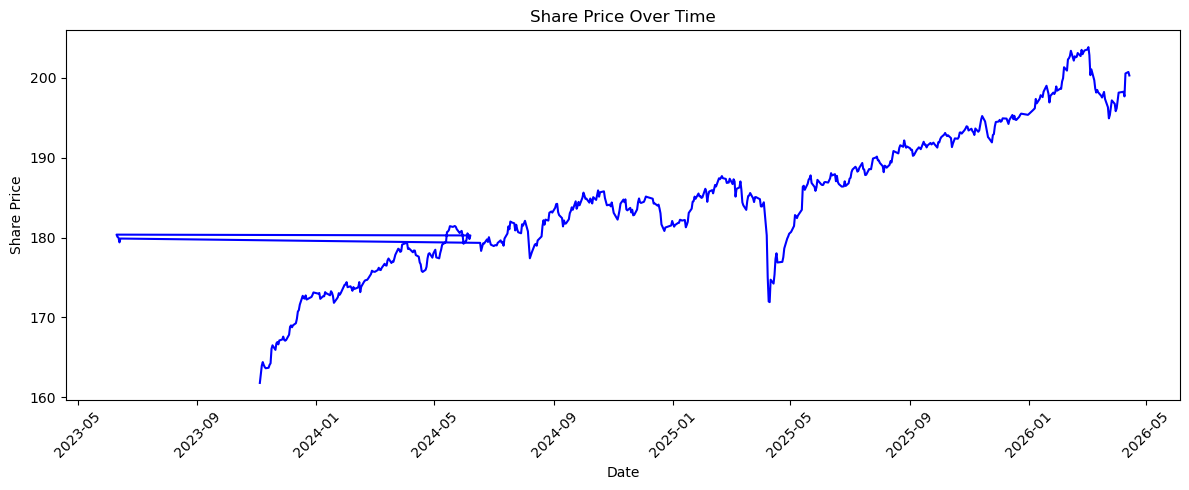

In [5]:
plt.figure(figsize=(12,5))
plt.plot(df["date"], df["share_price"], color="blue", label="Share Price")
plt.title("Share Price Over Time")
plt.xlabel("Date")
plt.ylabel("Share Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Good visualisation!

But we need some more variables to perform our analysis ;)

Let's create some lags for the share price and the daily return, together with moving averages (MA) and some future targets!

In [6]:
#Lag features
df["share_price_lag1"] = df["share_price"].shift(1)
df["share_price_lag5"] = df["share_price"].shift(5)
df["daily_return_lag1"] = df["daily_return"].shift(1)

#Moving Average (MA) 5 and 20 days
df["ma5"] = df["share_price"].rolling(window=5).mean()
df["ma20"] = df["share_price"].rolling(window=20).mean()

#1-week target (N.B: 5 working days)
df["share_price-next5"] = df["share_price"].shift(-5)
df["daily_return_next5"] = df["daily_return"].shift(-5)
df["direction_next5"] = (df["share_price-next5"] > df["share_price"]).astype(int)

df = df.dropna()

print(df.shape)
print(df.head())

(577, 16)
         date  n_shares  purchase_value  counter_value   var_pct  var_euro  \
22 2023-11-30    14.687          2499.8        2453.90 -0.018361    -45.90   
23 2023-12-01    14.687          2499.8        2455.23 -0.017829    -44.57   
25 2023-12-04    14.687          2499.8        2464.92 -0.013953    -34.88   
26 2023-12-05    14.687          2499.8        2479.46 -0.008137    -20.34   
27 2023-12-06    14.687          2499.8        2481.96 -0.007137    -17.84   

    share_price  daily_return  share_price_lag1  share_price_lag5  \
22   167.079730     -0.000542        167.170287        166.620140   
23   167.170287      0.000542        167.079730        167.109689   
25   167.830054      0.003947        167.170287        167.230204   
26   168.820000      0.005899        167.830054        167.589705   
27   168.990000      0.001007        168.820000        167.170287   

    daily_return_lag1         ma5        ma20  share_price-next5  \
22          -0.002503  167.235923  165

Alright, let's start playing now!

In [7]:
#Common features to all the models
features = [
    "n_shares", "purchase_value", "counter_value", "var_pct", "var_euro", 
    "share_price_lag1", "share_price_lag5", "daily_return_lag1", "ma5", "ma20"]

#Target for the models
X = df[features]

y_price = df["share_price-next5"] #Model 1: share price
y_return = df["daily_return_next5"] #Model 2: daily return
y_direction = df["direction_next5"] #Model 3: direction (up/down)

print(X.shape)
print(X.head())

(577, 10)
    n_shares  purchase_value  counter_value   var_pct  var_euro  \
22    14.687          2499.8        2453.90 -0.018361    -45.90   
23    14.687          2499.8        2455.23 -0.017829    -44.57   
25    14.687          2499.8        2464.92 -0.013953    -34.88   
26    14.687          2499.8        2479.46 -0.008137    -20.34   
27    14.687          2499.8        2481.96 -0.007137    -17.84   

    share_price_lag1  share_price_lag5  daily_return_lag1         ma5  \
22        167.170287        166.620140          -0.002503  167.235923   
23        167.079730        167.109689          -0.000542  167.248042   
25        167.170287        167.230204           0.000542  167.368013   
26        167.830054        167.589705           0.003947  167.614071   
27        168.820000        167.170287           0.005899  167.978014   

          ma20  
22  165.426938  
23  165.695961  
25  165.889959  
26  166.110969  
27  166.358481  


Let's divide the data into train and test sets

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_price, y_test_price = train_test_split(X, y_price, test_size=0.2, shuffle=False)
X_train, X_test, y_train_return, y_test_return = train_test_split(X, y_return, test_size=0.2, shuffle=False)
X_train, X_test, y_train_dir, y_test_dir = train_test_split(X, y_direction, test_size=0.2, shuffle=False)

print(f"Train: {X_train.shape[0]} righe")
print(f"Test: {X_test.shape[0]} righe")

Train: 461 righe
Test: 116 righe


Model 1 - Regression to forecast the share price

Which metrics are we adopting?
- RMSE (Random Mean Square Error); the lower, the better
- MAE (Mean Absolute Error); the lower, the better
- R² (classical linear regression coefficient to explain the data variance); closer to 1

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

#Model training
model_price = LinearRegression()
model_price.fit(X_train, y_train_price)

#Forecasting
y_pred_price = model_price.predict(X_test)

#Metrics
rmse = np.sqrt(mean_squared_error(y_test_price, y_pred_price))
mae = mean_absolute_error(y_test_price, y_pred_price)
r2 = r2_score(y_test_price, y_pred_price)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

RMSE: 9.6716
MAE: 7.6911
R²: -7.9452


Well, it seems we haven't chosen the best model 😅                
A negative R² value isn't a good signal.

But it sounds logical!
We are dealing with financial time series, which are characterised by non-linearity, time dependance and volatility.

To be honest, the time period includes significant events which are visible from the chart too:
- first of all, the time series begins in November 2023, where the negative values come from the excerbation of the conflict in the Middle-East
- a quick negative shock is visible around April 2025, when Donald Trump announced the USA tariffs on imports, which rapidly reverse towards positive values
- a more recent decline is registered during the further tensions in the Middle-East, with the direct involvement of Iran and the shut of the Strait of Hormuz

Let's see if a Random Forest model could perform better!

Model 2 - Random Forest to predict the share prices

In [10]:
from sklearn.ensemble import RandomForestRegressor

model_rf_price = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf_price.fit(X_train, y_train_price)

y_pred_rf_price = model_rf_price.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test_price, y_pred_rf_price))
mae_rf = mean_absolute_error(y_test_price, y_pred_rf_price)
r2_rf = r2_score(y_test_price, y_pred_rf_price)

print(f"RMSE: {rmse_rf:.4f}")
print(f"MAE: {mae_rf:.4f}")
print(f"R²: {r2_rf:.4f}")

RMSE: 10.2782
MAE: 8.4718
R²: -9.1027


Noniin, it went worse than expected :(
The reason stands in the inner complexity of financial markets.
Our ambitious goal is to forecast share prices in 5 days, which is particularly hard (especially in the current geopolitical situation)

To reduce the complexity, let's focus on predicting only the price direction!

Model 3 - Direction classification (up or down)

We use 4 different metrics:
* Accuracy (% of correct forecasting); better if close to 1
* Precision (How reliable the model is when predicting a movement); better if close to 1
* Recall (How many real directions the model individuates); better if close to 1
* F1-score (Weighted average of Precision and Recall); better if close to 1

Accuracy: 0.3707

Classification Report:
              precision    recall  f1-score   support

           0       0.35      1.00      0.52        39
           1       1.00      0.05      0.10        77

    accuracy                           0.37       116
   macro avg       0.67      0.53      0.31       116
weighted avg       0.78      0.37      0.24       116



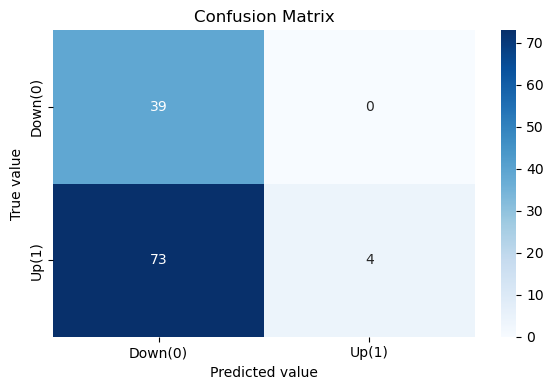

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

#Training the model
model_dir = RandomForestClassifier(n_estimators=100, random_state=42)
model_dir.fit(X_train, y_train_dir)

#Forecasting
y_pred_dir = model_dir.predict(X_test)

#Metrics
accuracy = accuracy_score(y_test_dir, y_pred_dir)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_dir, y_pred_dir))

#Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test_dir, y_pred_dir), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Down(0)', 'Up(1)'], yticklabels=['Down(0)', 'Up(1)'])
plt.xlabel('Predicted value')
plt.ylabel('True value')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

Umh, Houston we have a problem 🤔
The model shows a class imbalance problem:
- it predicts a decrease quite always (Recall = 1.00 for Down(0) and 0.05 for Up(1) )
- test set containts 39 Downs and 77 Ups, so the model ignores the majority class
- really a bad accuracy (37%...)

But why this happens?
Well, probabily because the investment fund is performing pretty well (yay, good news for the investors 🥳) so the majority of the observations are Ups

Let's try to balance the classes

Accuracy: 0.3707

Classification Report:
              precision    recall  f1-score   support

           0       0.35      1.00      0.52        39
           1       1.00      0.05      0.10        77

    accuracy                           0.37       116
   macro avg       0.67      0.53      0.31       116
weighted avg       0.78      0.37      0.24       116



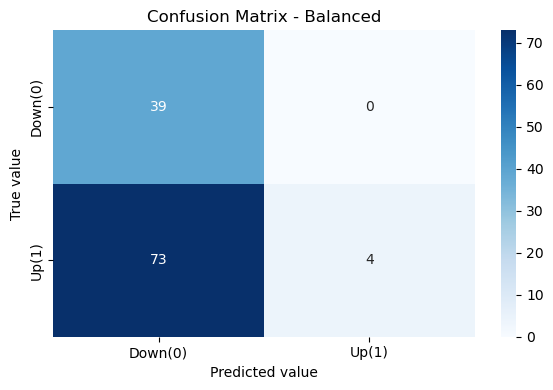

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Correcting the imblance with class_weight
model_dir_balanced = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_dir_balanced.fit(X_train, y_train_dir)


#Forecasting
y_pred_dir_balanced = model_dir_balanced.predict(X_test)

#Metrics
accuracy = accuracy_score(y_test_dir, y_pred_dir_balanced)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_dir, y_pred_dir_balanced))

#Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test_dir, y_pred_dir_balanced), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Down(0)', 'Up(1)'], yticklabels=['Down(0)', 'Up(1)'])
plt.xlabel('Predicted value')
plt.ylabel('True value')
plt.title('Confusion Matrix - Balanced')
plt.tight_layout()
plt.show()

Alright, it seems that we are trying to do a too ambitious job here with a 5-day forecasting 🥲
Let's try to simplify the analysis by predicting a 1-days horizon

In [13]:
#New target: direction next day
df["direction_next1"] = (df["share_price"].shift(-1) > df["share_price"]).astype(int)
df_model = df.dropna(subset=["direction_next1"])

#Split
X2 = df_model[features]
y_dir1 = df_model["direction_next1"]

X_train2, X_test2, y_train_dir1, y_test_dir1 = train_test_split(
    X2, y_dir1, test_size=0.2, shuffle=False
)

#Model
model_dir1 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)
model_dir1.fit(X_train2, y_train_dir1)

y_pred_dir1 = model_dir1.predict(X_test2)

print(f"Accuracy: {accuracy_score(y_test_dir1, y_pred_dir1):.4f}")
print(classification_report(y_test_dir1, y_pred_dir1))

Accuracy: 0.4569
              precision    recall  f1-score   support

           0       0.45      0.98      0.61        51
           1       0.75      0.05      0.09        65

    accuracy                           0.46       116
   macro avg       0.60      0.51      0.35       116
weighted avg       0.62      0.46      0.32       116



Okay, no good results for a ML project
Let's try with a simple clustering, based on the K-means method

c:\Users\utente\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\utente\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\utente\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\utente\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

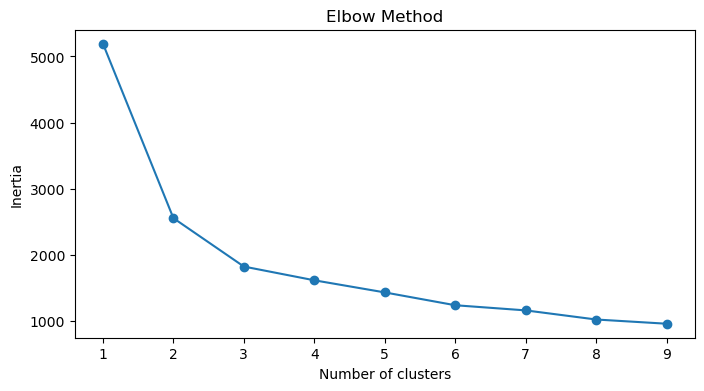

In [14]:
cluster_features = ["share_price", "daily_return", 
                    "share_price_lag1", "share_price_lag5", "daily_return_lag1", "ma5", "ma20",
                    "var_pct", "var_euro"]

from sklearn.preprocessing import StandardScaler

#Normalisation
X_cluster = df[cluster_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

#Choosing the number of clusters with the Elbow method
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
for k in range (1,10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,4))
plt.plot(range(1,10), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')        
plt.ylabel('Inertia')
plt.show()

It seems that the most appropriate number of clusters is 3 (literally, the "elbow" in the graph)

c:\Users\utente\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


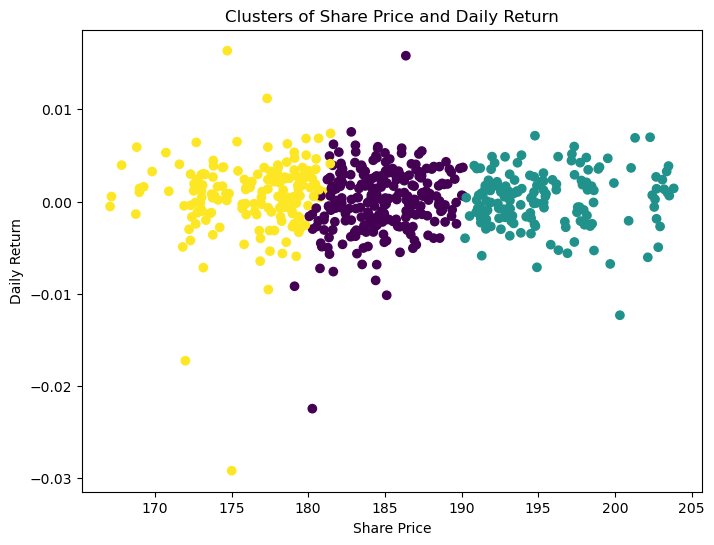

,share_price,daily_return,share_price_lag1,share_price_lag5,daily_return_lag1,ma5,ma20,var_pct,var_euro
cluster,,,,,,,,,
0,184.806508,0.000108,184.787183,184.528333,0.000327,184.715032,184.105407,0.066546,257.466548
1,195.519423,0.000270,195.467821,195.280897,0.000264,195.422487,195.058708,0.121220,429.398526
2,176.156805,0.000618,176.050002,175.913847,0.000255,176.028439,175.902946,0.029342,89.201420


In [19]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(df["share_price"], df["daily_return"], c=df["cluster"], cmap="viridis")
plt.xlabel("Share Price")
plt.ylabel("Daily Return")
plt.title("Clusters of Share Price and Daily Return")   
plt.show()

df.groupby("cluster")[cluster_features].mean()

Okay, let's see what we have built

*Cluster 1: High price, moderate return*

This cluster includes days where share_price is at the highest points, daily_return is positive, MAs are both high (highlighting an upward trend) and the variation are high, leading to significant returns.

*Cluster 0: Normal price, zero-return*

This cluster incorporates days where share_price is average (around 184.8), daily_return is around 0, MAs are similar and the variations are on average.
The fund is neither increasing or decreasing significantly

*Cluster 2: Low price, higher return*

Lastly, the days of this cluster show a low share_price (around 176), higher daily_returns (describing wider variations), low MAs and very low variations, leading to reduced incomes.
This underlines a stage where the market has spent trouble or uncertain days